# Team Members
*   Χρήστος Πετρόπουλος 1115202100156
*   Μαρίνα Παπαδημητρίου 1115202100136


In [ ]:
!pip install matlib
!pip install pandas
!pip install wordcloud
!pip install langdetect
!pip install vaderSentiment

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.1 MB/s eta 0:00:00


In [ ]:
import matlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import sys
import os
import folium
import nltk
import pickle

from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#### Part 1 (!At the end of the warnings are the final results!)

<ipython-input-35-8d5e5d752cae>:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  small_df.loc[:, 'truncated_comments'] = small_df['comments'].apply(truncate_to_max_length)
<ipython-input-35-8d5e5d752cae>:118: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  small_df.loc[:, 'en_comments'] = small_df['truncated_comments'].apply(detect_language)
<ipython-input-35-8d5e5d752cae>:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

      listing_id                                 truncated_comments     label  \
0          10595  the apartment was wonderful, fully equiped, be...  POSITIVE   
1          10595  emmanouil was an excellent host. he provided u...  POSITIVE   
2          10595  manos is a very good host, he is kind and help...  POSITIVE   
3          10595  our stay in emmanouil home was comfortable, qu...  POSITIVE   
4          10595  fantastic accommodation very well located to v...  POSITIVE   
...          ...                                                ...       ...   
1995       80598  great spot to explore athens. only about 10 mi...  POSITIVE   
1996       80598  unfortunately i was not able to visit athens. ...  POSITIVE   
1998       80598  staying at leandro's apartment was lovely! the...  POSITIVE   
1999       80598  the stay was perfect. had everything you neede...  POSITIVE   
2000       80598  leandros apartment felt very homey. he left ju...  POSITIVE   

         score       date  

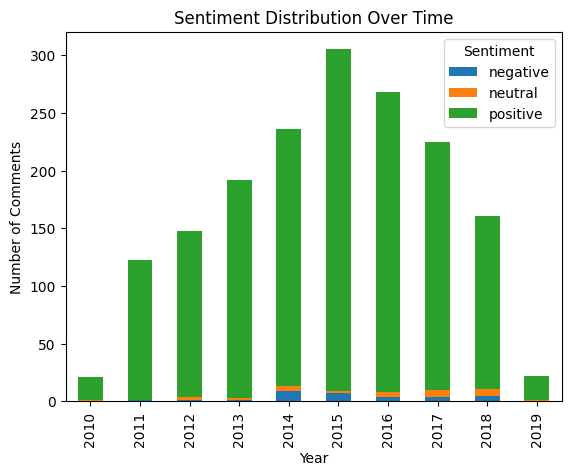

In [ ]:
from pyexpat import model
from transformers import pipeline, AutoTokenizer
from langdetect import detect, LangDetectException
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name)
# Load the sentiment-analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model=model_name)
analyzer = SentimentIntensityAnalyzer()

# Function to split text into chunks of max_length
def split_into_chunks(text, max_length=512):
    tokens = tokenizer.encode(text, truncation=False, add_special_tokens=False)
    chunks = [tokens[i:i + max_length] for i in range(0, len(tokens), max_length)]
    return [tokenizer.decode(chunk, skip_special_tokens=True) for chunk in chunks]

# Function to detect the language of the comments
def detect_language(text):
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'

# Function to analyze sentiment for long texts
def analyze_long_text(text):
    chunks = split_into_chunks(text)
    sentiments = [sentiment_analyzer(chunk)[0] for chunk in chunks]
    return sentiments

# Function to aggregate sentiment results
def aggregate_sentiment_results(sentiments):
    # Check if sentiments is empty or None
    if not sentiments:
        print("No sentiments provided. Returning default values.")
        return 'neutral', 0.0  # Default values for empty input

    try:
        # Determine the most frequent sentiment label
        labels = [s['label'] for s in sentiments]
        if not labels:
            print("No labels found in sentiments. Returning default values.")
            return 'neutral', 0.0  # Default values if no labels are found

        label = max(set(labels), key=labels.count)

        # Calculate the average sentiment score
        scores = [s['score'] for s in sentiments]
        if not scores:
            print("No scores found in sentiments. Returning default values.")
            return 'neutral', 0.0  # Default values if no scores are found

        score = sum(scores) / len(scores)

        return label, score
    except Exception as e:
        print(f"Error in aggregate_sentiment_results: {e}")
        return 'neutral', 0.0  # Return default values in case of an error

# Function to truncate text to a maximum of max_length tokens
def truncate_to_max_length(text, max_length=500):
    tokens = tokenizer.encode(text, truncation=True, max_length=max_length, add_special_tokens=False)
    return tokenizer.decode(tokens, skip_special_tokens=True)


# Function to classify sentiment
def classify_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'


# Sample DataFrame with IDs and comments
df_april_2019 = pd.read_csv('/content/drive/MyDrive/data/2019/april/reviews.csv')
df_febrouary_2019 = pd.read_csv('/content/drive/MyDrive/data/2019/febrouary/reviews.csv')
df_march_2019 = pd.read_csv('/content/drive/MyDrive/data/2019/march/reviews.csv')

# Add a new column named 'month' to indicate the month of each row
df_april_2019['month'] = 'April'
df_febrouary_2019['month'] = 'February'
df_march_2019['month'] = 'March'

# Concat the dataframes
df = pd.concat([df_april_2019, df_febrouary_2019, df_march_2019], ignore_index=True)
# Specify which columns you want to keep
df['date'] = pd.to_datetime(df['date'])
columns_to_keep = ['listing_id', 'comments','month' , 'date']
# Keep only the specified columns in the DataFrame
df = df.loc[:, columns_to_keep]
# Ensure comments are strings
df['comments'] = df['comments'].astype(str)
# Drop a row if a value in a row has NaN
df = df.dropna(how='any')

df = df.loc[0:2000]

# Split DataFrame into smaller ones
split_size = 100
num_splits = len(df) // split_size + (1 if len(df) % split_size != 0 else 0)
dataframes = []

for i in range(num_splits):
    start_row = i * split_size
    end_row = (i + 1) * split_size
    smaller_df = df.iloc[start_row:end_row]
    dataframes.append(smaller_df)


df_english = []
for idx, small_df in enumerate(dataframes):
    # Drop rows that don't have English comments
    small_df.loc[:, 'truncated_comments'] = small_df['comments'].apply(truncate_to_max_length)
    small_df.loc[:, 'en_comments'] = small_df['truncated_comments'].apply(detect_language)
    df_english.append(small_df[small_df['en_comments'] == 'en'].copy())

# Process the dataset in chunks to avoid memory issues
batch_size = 100
results = []

for idx, small_df in enumerate(df_english):
    batch = small_df

    # Apply sentiment analysis
    batch['sentiments'] = batch['truncated_comments'].apply(analyze_long_text)

    # Aggregate sentiment results
    batch['label'], batch['score'] = zip(*batch['sentiments'].apply(aggregate_sentiment_results))

    # Append results
    results.append(batch[['listing_id', 'truncated_comments', 'label', 'score' ,  'date']])

# Concatenate all batches
final_df = pd.concat(results)


print(final_df)

final_df['date'] = final_df['date'].dt.year

# Apply sentiment classification
final_df['sentiment'] = final_df['truncated_comments'].apply(classify_sentiment)

# Aggregate sentiment counts by year
sentiment_counts = final_df.groupby(['date', 'sentiment']).size().unstack().fillna(0)

# Plot the histogram
sentiment_counts.plot(kind='bar', stacked=True)
plt.xlabel('Year')
plt.ylabel('Number of Comments')
plt.title('Sentiment Distribution Over Time')
plt.legend(title='Sentiment')
plt.show()


#### Part 2
### Splitting the dataset into train and test sets

In [ ]:
from sklearn.model_selection import train_test_split
# Split the dataset into training and testing sets (80% train, 20% test)
train_df, test_df = train_test_split(final_df, test_size=0.2, random_state=42)

# Save the datasets
train_df.to_csv('train.tsv', sep='\t', index=False)
test_df.to_csv('test.tsv', sep='\t', index=False)


###Extract features using TF-IDF and word embeddings

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=100)
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['truncated_comments'])

# Save TF-IDF features and vectorizer using pickle
with open('X_train_tfidf.pkl', 'wb') as f:
    pickle.dump(X_train_tfidf, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)


###Word Embeddings (using Gensim's Word2Vec)

In [ ]:
from gensim.models import Word2Vec

# Train Word2Vec model
sentences = [comment.split() for comment in train_df['truncated_comments']]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

# Save Word2Vec model using pickle
with open('w2v_model.pkl', 'wb') as f:
    pickle.dump(w2v_model, f)

# Function to get average word vectors
def get_avg_word2vec(comment, model, vector_size):
    words = comment.split()
    feature_vec = np.zeros((vector_size,), dtype="float32")
    n_words = 0
    for word in words:
        if word in model.wv.key_to_index:
            n_words += 1
            feature_vec = np.add(feature_vec, model.wv[word])
    if n_words > 0:
        feature_vec = np.divide(feature_vec, n_words)
    return feature_vec

# Transform comments to word embeddings
X_train_w2v = np.array([get_avg_word2vec(comment, w2v_model, 100) for comment in train_df['truncated_comments']])

# Save Word2Vec embeddings using pickle
with open('X_train_w2v.pkl', 'wb') as f:
    pickle.dump(X_train_w2v, f)


###Train and evaluate classifiers

In [ ]:
import pickle
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Load labels for training
y_train = train_df['label']

# Initialize classifiers
svm = SVC()
rf = RandomForestClassifier()
knn = KNeighborsClassifier()

# Train classifiers with TF-IDF features
svm.fit(X_train_tfidf, y_train)
rf.fit(X_train_tfidf, y_train)
knn.fit(X_train_tfidf, y_train)

# Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

# Train classifiers with Word2Vec embeddings
svm.fit(X_train_w2v, y_train)
rf.fit(X_train_w2v, y_train)
knn.fit(X_train_w2v, y_train)

# Save Word2Vec model
with open('w2v_model.pkl', 'wb') as f:
    pickle.dump(w2v_model, f)

# Function to evaluate model using cross-validation
def cross_val_evaluate(model, X, y):
    precision_scorer = make_scorer(precision_score, average='weighted', zero_division=1)
    recall_scorer = make_scorer(recall_score, average='weighted', zero_division=1)
    f1_scorer = make_scorer(f1_score, average='weighted', zero_division=1)

    precision = cross_val_score(model, X, y, cv=10, scoring=precision_scorer)
    recall = cross_val_score(model, X, y, cv=10, scoring=recall_scorer)
    f1 = cross_val_score(model, X, y, cv=10, scoring=f1_scorer)
    accuracy = cross_val_score(model, X, y, cv=10, scoring='accuracy')
    return np.mean(precision), np.mean(recall), np.mean(f1), np.mean(accuracy)

# Evaluate classifiers with TF-IDF features using cross-validation
svm_tfidf_results = cross_val_evaluate(svm, X_train_tfidf, y_train)
rf_tfidf_results = cross_val_evaluate(rf, X_train_tfidf, y_train)
knn_tfidf_results = cross_val_evaluate(knn, X_train_tfidf, y_train)

# Evaluate classifiers with Word2Vec embeddings using cross-validation
svm_w2v_results = cross_val_evaluate(svm, X_train_w2v, y_train)
rf_w2v_results = cross_val_evaluate(rf, X_train_w2v, y_train)
knn_w2v_results = cross_val_evaluate(knn, X_train_w2v, y_train)

# Save SVM, Random Forest, and KNN models
with open('svm_model_tfidf.pkl', 'wb') as f:
    pickle.dump(svm, f)

with open('rf_model_tfidf.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('knn_model_tfidf.pkl', 'wb') as f:
    pickle.dump(knn, f)

with open('svm_model_w2v.pkl', 'wb') as f:
    pickle.dump(svm, f)

with open('rf_model_w2v.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('knn_model_w2v.pkl', 'wb') as f:
    pickle.dump(knn, f)

# Print results
print("TF-IDF Cross-Validation Results on train models")
print("SVM: ", svm_tfidf_results)
print("Random Forest: ", rf_tfidf_results)
print("KNN: ", knn_tfidf_results)

print("Word Embeddings Cross-Validation Results on train models")
print("SVM: ", svm_w2v_results)
print("Random Forest: ", rf_w2v_results)
print("KNN: ", knn_w2v_results)


TF-IDF Cross-Validation Results on train models
SVM:  (0.9539288007162711, 0.9514705882352942, 0.9326385534279318, 0.9514705882352942)
Random Forest:  (0.9539288007162711, 0.9522058823529411, 0.9326385534279318, 0.9514705882352942)
KNN:  (0.9367170010358865, 0.9463235294117647, 0.9320631197524432, 0.9463235294117647)
Word Embeddings Cross-Validation Results on train models
SVM:  (0.9459450692041521, 0.9426470588235294, 0.9148195607574076, 0.9426470588235294)
Random Forest:  (0.9474251883234382, 0.95, 0.9310709768852563, 0.9492647058823529)
KNN:  (0.9236793678193512, 0.9426470588235294, 0.9263459334160808, 0.9426470588235294)


###Cross-Validation

In [ ]:
from sklearn.metrics import classification_report
import pickle
import numpy as np

# Load trained models
with open('svm_model_tfidf.pkl', 'rb') as f:
    svm_tfidf = pickle.load(f)

with open('rf_model_tfidf.pkl', 'rb') as f:
    rf_tfidf = pickle.load(f)

with open('knn_model_tfidf.pkl', 'rb') as f:
    knn_tfidf = pickle.load(f)

with open('svm_model_w2v.pkl', 'rb') as f:
    svm_w2v = pickle.load(f)

with open('rf_model_w2v.pkl', 'rb') as f:
    rf_w2v = pickle.load(f)

with open('knn_model_w2v.pkl', 'rb') as f:
    knn_w2v = pickle.load(f)

# Load TF-IDF vectorizer and transform test data
with open('tfidf_vectorizer.pkl', 'rb') as f:
    tfidf_vectorizer = pickle.load(f)

X_test_tfidf = tfidf_vectorizer.transform(test_df['truncated_comments'])

# Convert sparse matrix to dense matrix
X_test_tfidf_dense = X_test_tfidf.toarray()

# Load Word2Vec model and transform test data
with open('w2v_model.pkl', 'rb') as f:
    w2v_model = pickle.load(f)

# Function to get average word vectors
def get_avg_word2vec(comment, model, vector_size):
    words = comment.split()
    feature_vec = np.zeros((vector_size,), dtype="float32")
    n_words = 0
    for word in words:
        if word in model.wv.key_to_index:
            n_words += 1
            feature_vec = np.add(feature_vec, model.wv[word])
    if n_words > 0:
        feature_vec = np.divide(feature_vec, n_words)
    return feature_vec

X_test_w2v = np.array([get_avg_word2vec(comment, w2v_model, 100) for comment in test_df['truncated_comments']])

# Predict using TF-IDF features
svm_predictions_tfidf = svm_tfidf.predict(X_test_tfidf_dense)
rf_predictions_tfidf = rf_tfidf.predict(X_test_tfidf_dense)
knn_predictions_tfidf = knn_tfidf.predict(X_test_tfidf_dense)

# Predict using Word2Vec embeddings
svm_predictions_w2v = svm_w2v.predict(X_test_w2v)
rf_predictions_w2v = rf_w2v.predict(X_test_w2v)
knn_predictions_w2v = knn_w2v.predict(X_test_w2v)

# Evaluate predictions compare with test labels
print("TF-IDF Results on Test Set")
print("SVM:")
print(classification_report(test_df['label'], svm_predictions_tfidf, zero_division=0))
print("Random Forest:")
print(classification_report(test_df['label'], rf_predictions_tfidf, zero_division=0))
print("KNN:")
print(classification_report(test_df['label'], knn_predictions_tfidf, zero_division=0))

print("Word Embeddings Results on Test Set")
print("SVM:")
print(classification_report(test_df['label'], svm_predictions_w2v, zero_division=0))
print("Random Forest:")
print(classification_report(test_df['label'], rf_predictions_w2v, zero_division=0))
print("KNN:")
print(classification_report(test_df['label'], knn_predictions_w2v, zero_division=0))


TF-IDF Results on Test Set
SVM:
              precision    recall  f1-score   support

    NEGATIVE       0.00      0.00      0.00        23
    POSITIVE       0.93      1.00      0.96       317

    accuracy                           0.93       340
   macro avg       0.47      0.50      0.48       340
weighted avg       0.87      0.93      0.90       340

Random Forest:
              precision    recall  f1-score   support

    NEGATIVE       0.00      0.00      0.00        23
    POSITIVE       0.93      1.00      0.96       317

    accuracy                           0.93       340
   macro avg       0.47      0.50      0.48       340
weighted avg       0.87      0.93      0.90       340

KNN:
              precision    recall  f1-score   support

    NEGATIVE       0.00      0.00      0.00        23
    POSITIVE       0.93      1.00      0.96       317

    accuracy                           0.93       340
   macro avg       0.47      0.50      0.48       340
weighted avg       0.8

<h1>Sentiment Analysis Project: Model Evaluation</h1>

<h2>Overview</h2>
<p>This project evaluates the performance of three machine learning models (SVM, Random Forest, and KNN) on sentiment analysis using two feature extraction methods: TF-IDF and Word Embeddings.</p>

<h2>Analysis</h2>
<p>All models show high accuracy (~95%) due to dataset imbalance. Models perform well on the "POSITIVE" class but struggle with the "NEGATIVE" class.</p>
<ul>
    <li>With <b>TF-IDF features</b>, all models fail to predict "NEGATIVE" comments effectively.</li>
    <li>With <b>Word Embeddings</b>, Random Forest shows improved handling of "NEGATIVE" comments, while SVM and KNN still struggle.</li>
</ul>

<h2>Conclusion</h2>
<p>Models are accurate for "POSITIVE" comments but not for "NEGATIVE" ones. Random Forest with Word Embeddings performs better for "NEGATIVE" comments.</p>


#### Part 3


### Load Pre-trained GloVe word vectors

In [ ]:
import pandas as pd
import numpy as np
import gensim.downloader as api
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import word_tokenize
from collections import Counter
import random

# Load pre-trained GloVe word vectors
word_vectors = api.load('glove-wiki-gigaword-100')

[==================================================] 100.0% 128.1/128.1MB downloaded


### Function to tokenize text and create dictionary of most common words without stopwords

In [ ]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

In [ ]:
def create_word_dictionary(text_series, top_n=100, min_count=2):
    word_counter = Counter()
    for text in text_series:
        tokens = word_tokenize(text.lower())  # Tokenize and convert to lowercase
        tokens = [word for word in tokens if word.isalpha() and word not in stop_words]  # Filter out stopwords
        word_counter.update(tokens)

    # Select top n most common words
    word_dict = dict(sorted(word_counter.items(), key=lambda x: x[1], reverse=True)[:top_n])
    return word_dict

# Create dictionary of most common words from 'truncated_comments'
word_dict = create_word_dictionary(final_df['truncated_comments'])

### Function to generate embeddings and similarity matrix

In [ ]:
def generate_embeddings_and_similarity(word_dict, word_vectors):
    # Filter word vectors to include only those in our dictionary
    filtered_word_vectors = {word: word_vectors[word] for word in word_dict if word in word_vectors.key_to_index}

    # Create a similarity matrix for all pairs of words in the dictionary
    word_list = list(filtered_word_vectors.keys())
    similarity_matrix = np.zeros((len(word_list), len(word_list)))

    for i, word1 in enumerate(word_list):
        for j, word2 in enumerate(word_list):
            if i <= j:  # Process each pair only once to save computation
                similarity = cosine_similarity([filtered_word_vectors[word1]], [filtered_word_vectors[word2]])[0][0]
                similarity_matrix[i, j] = similarity
                similarity_matrix[j, i] = similarity  # Symmetry

    return word_list, similarity_matrix

# Generate embeddings and similarity matrix
word_list, similarity_matrix = generate_embeddings_and_similarity(word_dict, word_vectors)

### Function to calculate neighborhood metrics using dictionary-based functions

In [ ]:
def calculate_neighborhood_metrics(word1, word2, word_list, similarity_matrix, N=5):
    def max_similarity_neighborhood_dict(word1, word2, word_list, similarity_matrix, N=5):
        idx_word1 = word_list.index(word1)
        idx_word2 = word_list.index(word2)

        neighbors_word1 = np.argsort(similarity_matrix[idx_word1])[-N:][::-1]
        neighbors_word2 = np.argsort(similarity_matrix[idx_word2])[-N:][::-1]

        alpha_ij = max(similarity_matrix[idx_word1, idx] for idx in neighbors_word2)
        alpha_ji = max(similarity_matrix[idx_word2, idx] for idx in neighbors_word1)

        return max(alpha_ij, alpha_ji)

    def correlation_neighborhood_similarities_dict(word1, word2, word_list, similarity_matrix, N=5):
        idx_word1 = word_list.index(word1)
        idx_word2 = word_list.index(word2)

        neighbors_word1 = np.argsort(similarity_matrix[idx_word1])[-N:][::-1]
        neighbors_word2 = np.argsort(similarity_matrix[idx_word2])[-N:][::-1]

        similarities_word1 = similarity_matrix[idx_word1, neighbors_word1]
        similarities_word2 = similarity_matrix[idx_word2, neighbors_word2]

        rho1 = np.corrcoef(similarities_word1, similarities_word2)[0, 1]
        rho2 = np.corrcoef(similarities_word2, similarities_word1)[0, 1]

        return max(rho1, rho2)

    def sum_squared_neighborhood_similarities_dict(word1, word2, word_list, similarity_matrix, N=5):
        idx_word1 = word_list.index(word1)
        idx_word2 = word_list.index(word2)

        neighbors_word1 = np.argsort(similarity_matrix[idx_word1])[-N:][::-1]
        neighbors_word2 = np.argsort(similarity_matrix[idx_word2])[-N:][::-1]

        sum_word1 = sum(similarity_matrix[idx_word1, idx] for idx in neighbors_word1)
        sum_word2 = sum(similarity_matrix[idx_word2, idx] for idx in neighbors_word2)

        return sum_word1 + sum_word2

    max_similarity_dict = max_similarity_neighborhood_dict(word1, word2, word_list, similarity_matrix, N=N)
    correlation_similarity_dict = correlation_neighborhood_similarities_dict(word1, word2, word_list, similarity_matrix, N=N)
    sum_squared_similarity_dict = sum_squared_neighborhood_similarities_dict(word1, word2, word_list, similarity_matrix, N=N)

    return max_similarity_dict, correlation_similarity_dict, sum_squared_similarity_dict


### Function to find random words from the dictionary

In [ ]:
def find_random_words(word_dict, num_words=2):
    random_words = random.sample(list(word_dict.keys()), num_words)
    return random_words

### Example

In [ ]:
# Example of using user input for random words
random_words = find_random_words(word_dict, num_words=2)
word1 = random_words[0]
word2 = random_words[1]

# Calculate neighborhood metrics for default N = 5
max_similarity, correlation_similarity, sum_squared_similarity = calculate_neighborhood_metrics(word1, word2, word_list, similarity_matrix)

# Print results for default N = 5
print(f"Randomly chosen words: '{word1}' and '{word2}'")
print(f"Maximum Similarity of Neighborhoods (Mn) for N=5: {max_similarity}")
print(f"Correlation of Neighborhood Similarities (Rn) for N=5: {correlation_similarity}")
print(f"Sum of Squared Neighborhood Similarities (Enθ) for N=5: {sum_squared_similarity}")
print()

# Analyze the impact of neighborhood size N on similarity metrics
N_values = [5, 10, 15, 20]

for N in N_values:
    max_similarity, correlation_similarity, sum_squared_similarity = calculate_neighborhood_metrics(word1, word2, word_list, similarity_matrix, N=N)
    print(f"N = {N}:")
    print(f"Maximum Similarity of Neighborhoods (Mn): {max_similarity}")
    print(f"Correlation of Neighborhood Similarities (Rn): {correlation_similarity}")
    print(f"Sum of Squared Neighborhood Similarities (Enθ): {sum_squared_similarity}")
    print()

# Function to print word neighborhoods for a chosen word and N
def print_word_neighborhood(word, word_list, similarity_matrix, N=5):
    idx_word = word_list.index(word)
    neighbors = np.argsort(similarity_matrix[idx_word])[-N:][::-1]

    print(f"Neighborhood of '{word}' (Top {N} similar words):")
    for i, idx in enumerate(neighbors, 1):
        similar_word = word_list[idx]
        similarity_score = similarity_matrix[idx_word, idx]
        print(f"{i}. {similar_word} (Similarity: {similarity_score:.4f})")

# Example of printing word neighborhoods for a chosen word and N
chosen_word = random.choice(list(word_dict.keys()))
N = 10  # Choose the neighborhood size

print_word_neighborhood(chosen_word, word_list, similarity_matrix, N=N)

Randomly chosen words: 'recommend' and 'away'
Maximum Similarity of Neighborhoods (Mn) for N=5: 0.6918186545372009
Correlation of Neighborhood Similarities (Rn) for N=5: 0.9644679342967946
Sum of Squared Neighborhood Similarities (Enθ) for N=5: 7.27981635928154

N = 5:
Maximum Similarity of Neighborhoods (Mn): 0.6918186545372009
Correlation of Neighborhood Similarities (Rn): 0.9644679342967946
Sum of Squared Neighborhood Similarities (Enθ): 7.27981635928154

N = 10:
Maximum Similarity of Neighborhoods (Mn): 0.7914853692054749
Correlation of Neighborhood Similarities (Rn): 0.9565090923237299
Sum of Squared Neighborhood Similarities (Enθ): 13.155488669872284

N = 15:
Maximum Similarity of Neighborhoods (Mn): 0.7914853692054749
Correlation of Neighborhood Similarities (Rn): 0.9568643586426354
Sum of Squared Neighborhood Similarities (Enθ): 18.74833983182907

N = 20:
Maximum Similarity of Neighborhoods (Mn): 0.7914853692054749
Correlation of Neighborhood Similarities (Rn): 0.96386088571047